## FIR vs IIR filter design

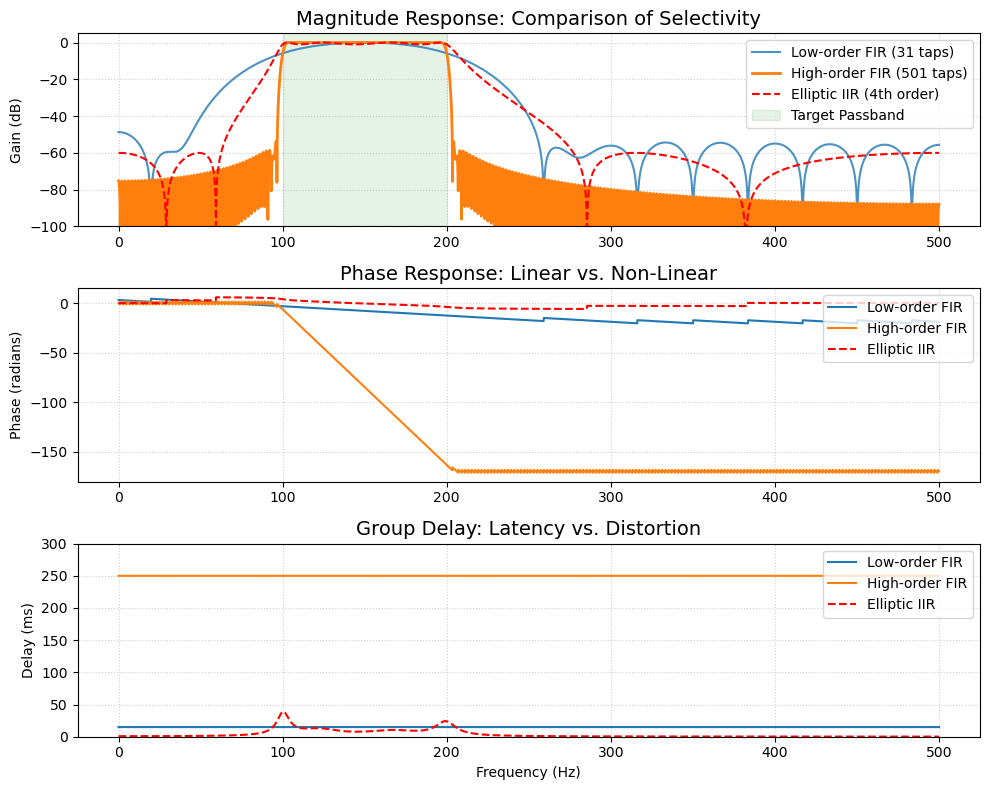

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# --- Configuration ---
fs = 1000.0       # Sampling frequency (Hz)
lowcut = 100.0    # Lower band edge
highcut = 200.0   # Upper band edge
nyq = 0.5 * fs

# 1. Low-order FIR (31 taps) - Window method
taps_low = 31
fir_low = signal.firwin(taps_low, [lowcut, highcut], pass_zero=False, fs=fs)

# 2. High-order FIR (501 taps) - Very sharp brick-wall
taps_high = 501
fir_high = signal.firwin(taps_high, [lowcut, highcut], pass_zero=False, fs=fs)

# 3. Elliptic IIR (4th order) - High performance but non-linear phase
# rp=1dB ripple in passband, rs=60dB attenuation in stopband
iir_b, iir_a = signal.ellip(4, rp=1, rs=60, Wn=[lowcut, highcut], btype='bandpass', fs=fs)

def get_response(b, a, fs):
    w, h = signal.freqz(b, a, worN=4000)
    freq = w * fs / (2 * np.pi)
    magnitude = 20 * np.log10(np.abs(h) + 1e-12)
    phase = np.unwrap(np.angle(h))
    # Group delay calculation
    _, gd = signal.group_delay((b, a), w=w)
    gd_ms = (gd / fs) * 1000  # Convert samples to milliseconds
    return freq, magnitude, phase, gd_ms

# Calculate data
f1, m1, p1, gd1 = get_response(fir_low, [1], fs)
f2, m2, p2, gd2 = get_response(fir_high, [1], fs)
f3, m3, p3, gd3 = get_response(iir_b, iir_a, fs)

# --- Plotting ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8))

# Subplot 1: Magnitude Response (ACHKH)
ax1.plot(f1, m1, label=f'Low-order FIR ({taps_low} taps)', alpha=0.8)
ax1.plot(f2, m2, label=f'High-order FIR ({taps_high} taps)', linewidth=2)
ax1.plot(f3, m3, label='Elliptic IIR (4th order)', linestyle='--', color='red')
ax1.axvspan(lowcut, highcut, color='green', alpha=0.1, label='Target Passband')
ax1.set_title('Magnitude Response: Comparison of Selectivity', fontsize=14)
ax1.set_ylabel('Gain (dB)')
ax1.set_ylim(-100, 5)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle=':', alpha=0.6)

# Subplot 2: Phase Response (FCHKH)
ax2.plot(f1, p1, label='Low-order FIR')
ax2.plot(f2, p2, label='High-order FIR')
ax2.plot(f3, p3, label='Elliptic IIR', linestyle='--', color='red')
ax2.set_title('Phase Response: Linear vs. Non-Linear', fontsize=14)
ax2.set_ylabel('Phase (radians)')
ax2.legend(loc='upper right')
ax2.grid(True, linestyle=':', alpha=0.6)

# Subplot 3: Group Delay (Time Alignment)
ax3.plot(f1, gd1, label='Low-order FIR')
ax3.plot(f2, gd2, label='High-order FIR')
ax3.plot(f3, gd3, label='Elliptic IIR', linestyle='--', color='red')
ax3.set_title('Group Delay: Latency vs. Distortion', fontsize=14)
ax3.set_ylabel('Delay (ms)')
ax3.set_xlabel('Frequency (Hz)')
ax3.set_ylim(0, 300) # Adjusted for high-order FIR delay
ax3.legend(loc='upper right')
ax3.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()